##### ARTI 560 - Computer Vision

## Image Classification with Vision Transformer (ViT) - Exercise

### Objective

In this exercise, you will test the pretrained Vision Transformer (ViT) model on 5 real-world images that you find online.

You will:

1. Download 5 images for different classes in [ImageNet](https://github.com/Waikato/wekaDeeplearning4j/blob/master/docs/user-guide/class-maps/IMAGENET.md).

2. Load the ImageNet class names from a [text file](https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt).

3. Use ViT to predict the class for each image.

4. Record whether the prediction was correct.

#### Important Note

For this exercise, you MUST use the following KerasHub components:

- [keras_hub.models.ViTImageClassifier](https://keras.io/keras_hub/api/models/vit/vit_image_classifier/)

- [keras_hub.models.ViTImageClassifierPreprocessor](https://keras.io/keras_hub/api/models/vit/vit_image_classifier_preprocessor/)

This ensures your input preprocessing (resizing + normalization) matches what the pretrained ViT model expects.

Do not replace the preprocessor with manual normalization (such as dividing by 255), because it may produce incorrect predictions.

In [2]:
#Import Libraries
import numpy as np
import matplotlib.pyplot as plt
import keras
import keras_hub #provides pretrained models like: ViT, Bert
import tensorflow as tf
from tensorflow.keras.utils import load_img, img_to_array
import requests
from PIL import Image
from io import BytesIO

In [3]:
#Load ViTImageClassifierPreprocessor (vit_base_patch16_224_imagenet preset)
preprocessor = keras_hub.models.ViTImageClassifierPreprocessor.from_preset('vit_base_patch16_224_imagenet')
#ViT-B16 model pre-trained on the ImageNet 1k dataset with image resolution of 224x224

In [4]:
#Load ViTImageClassifier (vit_base_patch16_224_imagenet preset)
model = keras_hub.models.ViTImageClassifier.from_preset('vit_base_patch16_224_imagenet')
#ViT-B16 model pre-trained on the ImageNet 1k dataset with image resolution of 224x224

In [5]:
#Load the images
classes_url = "https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt"
class_names = requests.get(classes_url).text.splitlines()

image_urls = [
    "https://raw.githubusercontent.com/shadenalsuhayan/arti560-computer-vision-labs/main/lab03-image-classification-vision-transformer-vit/images/ipod.jpeg",
    "https://raw.githubusercontent.com/shadenalsuhayan/arti560-computer-vision-labs/main/lab03-image-classification-vision-transformer-vit/images/teapot.jpeg",
    "https://raw.githubusercontent.com/shadenalsuhayan/arti560-computer-vision-labs/main/lab03-image-classification-vision-transformer-vit/images/Banana.jpeg",
    "https://raw.githubusercontent.com/shadenalsuhayan/arti560-computer-vision-labs/main/lab03-image-classification-vision-transformer-vit/images/envelope.jpeg",
    "https://raw.githubusercontent.com/shadenalsuhayan/arti560-computer-vision-labs/main/lab03-image-classification-vision-transformer-vit/images/icecream.jpeg"
]

expected_labels = [
    "iPod",
    "teapot",
    "banana",
    "envelope",
    "ice cream"
]

images = []
for url in image_urls:
    response = requests.get(url)
    img = Image.open(BytesIO(response.content)).convert("RGB")
    # Resize here to ensure uniformity before batching
    img = img.resize((224, 224))
    images.append(np.array(img))

image_batch = np.array(images)

In [6]:
#Predict classes
predictions = model.predict(image_batch)
predicted_indices = np.argmax(predictions, axis = 1)
predicted_labels = [class_names[i] for i in predicted_indices]

1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step


Image File     	Predicted Label     	True Label     	Correct?
_________________________________________________________________
ipod.jpeg      	iPod                	iPod           	Yes
teapot.jpeg    	teapot              	teapot         	Yes
Banana.jpeg    	banana              	banana         	Yes
envelope.jpeg  	envelope            	envelope       	Yes
icecream.jpeg  	ice cream           	ice cream      	Yes


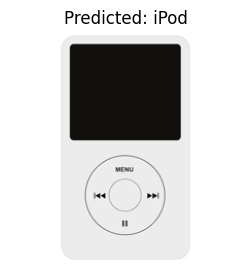

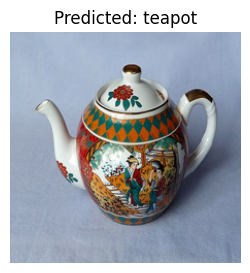

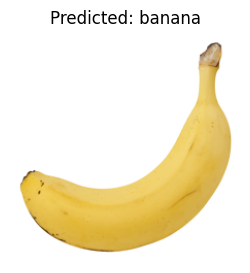

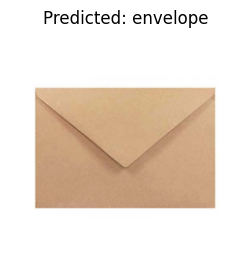

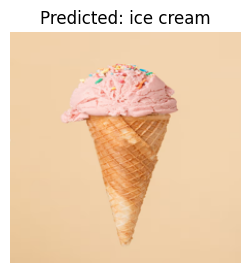

In [8]:
print(f"{'Image File':<15}\t{'Predicted Label':<20}\t{'True Label':<15}\t{'Correct?'}")
print("_"*65)

for i in range(len(images)):
    pred = predicted_labels[i]
    true = expected_labels[i]
    #flexiblity matching for ice cream and icecream
    is_correct = "Yes" if true.lower().replace(" ", "") in pred.lower().replace(" ", "") or \
                         pred.lower().replace(" ", "") in true.lower().replace(" ", "") else "No"

    file_name = image_urls[i].split('/')[-1]
    print(f"{file_name:<15}\t{pred:<20}\t{true:<15}\t{is_correct}")

for i, img in enumerate(images):
    plt.figure(figsize=(3,3))
    plt.imshow(img)
    plt.title(f"Predicted: {predicted_labels[i]}")
    plt.axis("off")
    plt.show()